# Algorithm Performance Measurement and Benchmarking
Runs the same engine used by `app.py` and shows tables, graphs and analysis.

In [1]:
import benchmark_engine as be
import matplotlib.pyplot as plt
%matplotlib inline
results = be.run_all()

## 1. Search algorithms (Linear vs Binary)

In [2]:
results['Search'].round(4)

,Algorithm,Size,Time_ms,Memory_KB,Operations
0,Linear Search,100,0.0146,0.1172,100
1,Binary Search,100,0.0041,0.0000,7
2,Linear Search,1000,0.3110,0.2070,1000
3,Binary Search,1000,0.0064,0.1562,10
4,Linear Search,10000,3.1129,0.2070,10000
5,Binary Search,10000,0.0130,0.1562,14
6,Linear Search,50000,19.6114,0.2070,50000
7,Binary Search,50000,0.0163,0.1562,16


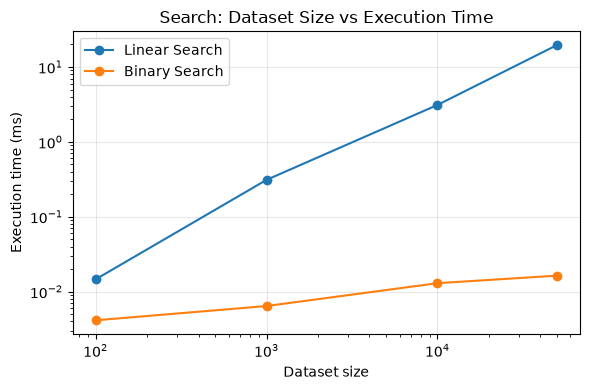

Linear Search: 0.0146 ms at n=100 -> 19.6114 ms at n=50000 (roughly linear).
Binary Search: 0.0041 ms at n=100 -> 0.0163 ms at n=50000 (almost flat (constant / logarithmic)).
Fastest at n=50000: Binary Search.


In [3]:
be.plot_comparison(results['Search'], *be.CHARTS['Search']); plt.show()
print('\n'.join(be.summarize(results['Search'])))

## 2. Factorial (Recursive vs Iterative)

In [4]:
results['Factorial'].round(4)

,Algorithm,Size,Time_ms,Memory_KB,Operations
0,Recursive Factorial,100,0.0887,0.4297,100
1,Iterative Factorial,100,0.0358,0.2266,99
2,Recursive Factorial,500,0.6651,8.3555,500
3,Iterative Factorial,500,0.3350,1.1289,499
4,Recursive Factorial,1000,1.7257,23.9805,1000
5,Iterative Factorial,1000,0.9039,2.3672,999


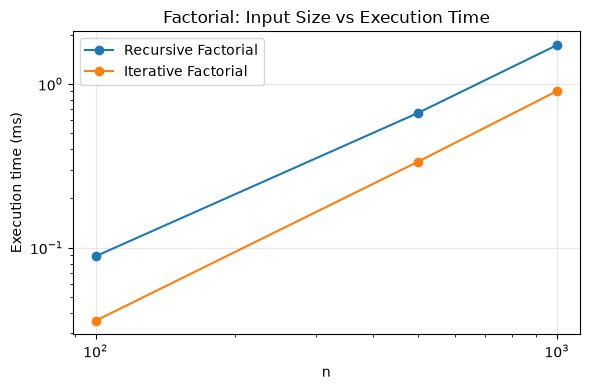

Recursive Factorial: 0.0887 ms at n=100 -> 1.7257 ms at n=1000 (roughly linear).
Iterative Factorial: 0.0358 ms at n=100 -> 0.9039 ms at n=1000 (between linear and quadratic).
Fastest at n=1000: Iterative Factorial.


In [5]:
be.plot_comparison(results['Factorial'], *be.CHARTS['Factorial']); plt.show()
print('\n'.join(be.summarize(results['Factorial'])))

## 3. Loops (Single vs Nested)

In [6]:
results['Loops'].round(4)

,Algorithm,Size,Time_ms,Memory_KB,Operations
0,Single Loop,100,0.0115,0.0938,100
1,Single Loop,1000,0.1920,0.1250,1000
2,Single Loop,5000,0.7702,0.1250,5000
3,Single Loop,10000,1.8265,0.1250,10000
4,Single Loop,50000,9.8556,0.1328,50000
5,Nested Loop,100,1.9655,0.1406,10000
6,Nested Loop,500,34.5902,0.2344,250000
7,Nested Loop,1000,101.2033,0.2344,1000000
8,Nested Loop,2000,655.1382,1.5234,4000000
9,Nested Loop,5000,3697.3775,1.8047,25000000


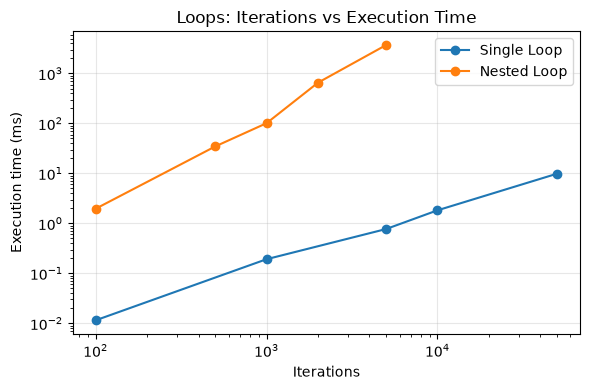

Single Loop: 0.0115 ms at n=100 -> 9.8556 ms at n=50000 (roughly linear).
Nested Loop: 1.9655 ms at n=100 -> 3697.3775 ms at n=5000 (roughly quadratic or worse).
Fastest at n=5000: Single Loop.


In [7]:
be.plot_comparison(results['Loops'], *be.CHARTS['Loops']); plt.show()
print('\n'.join(be.summarize(results['Loops'])))

## 4. Complexity: theory vs observed

In [8]:
be.complexity_table(results)

,Algorithm,Theoretical,Largest Size,Time (ms),Memory (KB),Log-log slope,Observed growth
0,Linear Search,O(n),50000,19.6114,0.21,1.14,Roughly linear
1,Binary Search,O(log n),50000,0.0163,0.16,0.23,Almost flat (constant / logarithmic)
2,Recursive Factorial,O(n),1000,1.7257,23.98,1.28,Roughly linear
3,Iterative Factorial,O(n),1000,0.9039,2.37,1.40,Between linear and quadratic
4,Single Loop,O(n),50000,9.8556,0.13,1.07,Roughly linear
5,Nested Loop,O(n^2),5000,3697.3775,1.80,1.94,Roughly quadratic or worse


## 5. Conclusions
- Binary search stays almost flat (O(log n)) while linear search grows linearly.
- Iterative factorial uses far less memory than recursive (no call stack); both grow faster than linear because big-integer multiplication gets costlier.
- Nested loop grows quadratically; a single loop grows linearly.
- Time-space trade-off: binary search needs sorted data (sorting cost up front), recursion trades memory for simpler code.